<p style='font-weight:bold;'><font size=6 color='black'>Predicting Company Bankruptcy</font></p>

<p style='font-weight:bold;'><font size=4 color='black'>Application of Machine Learning Algorithms on Data from NYSE/NASDAQ and Taiwan Stock Exchange</font></p>

### <font color='289C4E' size= 5>Table of Contents<font><a class='anchor' id='top'></a>
- [<font size= 2>0. Introduction](#section0)
- [<font size= 2>1. NYSE/NASDAQ-  Exploring various ML algorithms](#section1)
    - [<font size= 2>1.1 EDA](#subsection11)
    - [<font size= 2>1.2 Data preprocessing and engineering](#subsection12)
    - [<font size= 2>1.3 Applying 7 ML algorithms to predict bankrumptycy](#subsection13)
- [<font size= 2>2. Taiwan Area - Deep diving into 3 ML algorithms combined with PCA and feature selection](#section2)
    - [<font size= 2>2.1 EDA](#subsection21)
    - [<font size= 2>2.2 Data preprocessing and engineering](#subsection22)
    - [<font size= 2>2.3 KNN/RF/LR combined with PCA/feature extraction](#subsection23)
- [<font size= 2>3. Conclusions](#section3)

<div style="color:black;
           display:fill;
           border-radius:5px;
           background-color:#ADD8E6;
           font-size:100%;
           letter-spacing:0.5px">

<p style="padding: 1px;
              color:white;">

    <p style='font-weight:bold;'>&nbsp; tl;dr? Here is the summary:</p><br>

&nbsp; 1. 🐶.<br>
<br>
&nbsp; 2. .<br>
<br>
&nbsp; 3.  🫵 .<br>
<br>
</p>
</div>

<h1 align="left"><font color='red'size=4>0. Introduction</font></h1><a class='anchor' id='section0'></a>

The occurrence of company bankruptcies poses a critical problem with far-reaching consequences, including job losses, economic instability, and financial setbacks for investors. Recent statistics indicate that over 6 million Americans between May 2020 and June 2021 were unable to work because employer closed or lost business, as reported by the U.S. Bureau of Labor Statistics. Additionally, research published by the University of Pennsylvania reveals that the bankruptcy of a company leads to a loss of approximately 20-45% for shareholders (Reindl et al., 2017). Given these detrimental effects, it is imperative to develop effective methods for predicting company bankruptcy, as it would aid in risk assessment, loss mitigation, and stabilization of employment and economics. Furthermore, the urgency to address this issue has been heightened in the wake of the COVID-19 pandemic. The global economy has experienced unprecedented disruption, with numerous industries facing challenges they have never encountered before. Reduced consumer spending, supply chain disruptions, and temporary closures have had a profound negative effect on the financial stability of businesses. As a result, a significant number of companies have faced financial difficulties, unable to sustain their operations and leading to a surge in bankruptcies or financial restructuring. Given the widespread impact of the pandemic on the global economy, predicting company bankruptcy has become even more critical. It is essential to develop robust and accurate models that can assess the financial health of companies in these unprecedented times. 

Much effort has been put into developing prediction models; however, predicting company bankruptcy is still a complex and challenging task, due to the numerous factors and variables involved. Traditional financial analysis methods, such as financial ratio analysis, cash flow analysis, and qualitative assessment (e.g., multiple discriminant analysis), have been the primary approaches employed in the field. However, these methods have certain limitations and may not adequately capture the dynamic nature of financial data and the intricate interrelationships between variables. To address the limitations of traditional modeling methods, we propose utilizing advanced machine learning techniques and predictive modeling algorithms for predicting company bankruptcy. Recent advancements in machine learning algorithms and increased computing power have made it possible to model complex financial data more accurately and efficiently. Additionally, the availability of large-scale financial datasets and alternative data sources provides a rich resource for training and validating predictive models

In a literature review on bankruptcy prediction (Narvekar and Guha, 2021), various machine learning models, such as logistic regression, random forest, k-nearest neighbor, gradient boosting, and neural networks, have been explored. However, none of these models were investigated in combination with PCA or feature selections, which has significantly impeded further performance improvements in these models. Many of the existing models assume linear relationships in the data and necessitate the construction of interaction variables with high polynomials, leading to extensive computation time when dealing with a substantial number of independent variables. To address these challenges, we propose deploying PCA and potential kernels to transform our linear models and capture non-linear patterns in the data, potentially alleviating the need for strict linear assumptions. Additionally, incorporating feature selection can also help reduce noise and enhance model performance. We aim to substantially improve the efficacy and efficiency of bankruptcy prediction, presenting a cutting-edge solution for this significant problem.

The overarching goal of this project is to develop and implement advanced machine learning techniques and predictive modeling algorithms to further improve the efficacy and efficiency of predicting company bankruptcy. Successful implementation of the proposed predictive models will have significant impacts across various sectors. It will enable businesses to proactively identify financial distress and take corrective actions to avoid bankruptcy, thus ensuring their survival and preserving jobs. Investors will be empowered to make more informed decisions, mitigating the risk of financial loss. Financial institutions can enhance their risk assessment processes and make sound lending decisions, which ultimately contribute to overall financial stability.

<h1 align="left"><font color='red' size=4>1. US Company Bankruptcy Prediction-  Exploring various ML algorithms </font></h1><a class='anchor' id='section1'></a>

In [1]:
#general
import pandas as pd 
import numpy as np
from scipy import stats
import imblearn

#preprocessing
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#ML algorithms
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel, VarianceThreshold,SelectKBest
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn.ensemble import RandomForestClassifier #random forest
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.svm import SVC #SVM
from sklearn.neural_network import MLPClassifier #neural network
from sklearn.naive_bayes import GaussianNB #naive bayes
from sklearn.tree import DecisionTreeClassifier #decision tree

#evaluation
from sklearn.model_selection import learning_curve
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, precision_score, recall_score, roc_auc_score, precision_recall_curve

#ploting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

<h1 align="left"><font color='blue'><font size = 2> 1.1 EDA </font></h1><a class='anchor' id='subsection11'></a>

(78682, 21)
False
(56434, 21)
0.934 0.066
0.931 0.049


,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
count,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000,56434.000000
mean,2006.955754,95.910156,112.796068,9.629794,16.055843,18.790250,-3.996500,26.544697,315.739873,176.032440,205.176816,38.503211,6.425864,63.236519,41.135747,-48.591189,176.032440,94.070297,159.976632
std,5.649395,133.534020,163.999971,19.814067,50.357297,38.940567,58.855512,41.433470,607.577095,237.932847,291.240364,90.011987,45.416701,100.900236,55.958389,434.210609,237.932847,145.936777,207.002030
min,1999.000000,-7.760000,-31.437000,0.000000,-1967.817000,0.000000,-3605.690000,-0.006000,0.000100,-1964.999000,0.001000,-0.023000,-1967.817000,-1964.999000,0.001000,-67264.200000,-1964.999000,0.001000,-31.437000
25%,2002.000000,10.163000,8.530250,0.606250,-2.874000,0.000000,-9.187000,1.517000,19.112325,13.359750,20.010250,0.000000,-5.314000,3.483250,5.268250,-73.591750,13.359750,7.673500,19.086250
50%,2006.000000,42.487000,38.573500,2.887000,2.510500,2.237000,-0.337500,8.721000,84.774600,66.795000,84.381500,1.023500,0.411000,23.009000,17.888500,-10.850500,66.795000,29.135000,68.013000
75%,2012.000000,128.937000,145.779750,10.800750,25.409500,17.399250,7.787750,32.997000,337.950225,247.359000,275.515250,21.702250,14.741750,86.936000,54.903750,23.047500,247.359000,110.325250,221.142250
max,2018.000000,2126.858000,957.174000,711.694000,484.191000,677.500000,551.412000,481.102000,7503.524600,1237.604000,3616.569000,748.271000,259.492000,653.010000,417.431000,1935.671000,1237.604000,791.459000,962.646000


3 ['company_name', 'status_label', 'year']
18 ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18']


Text(0.5, 1.0, 'Correlation Heatmap')

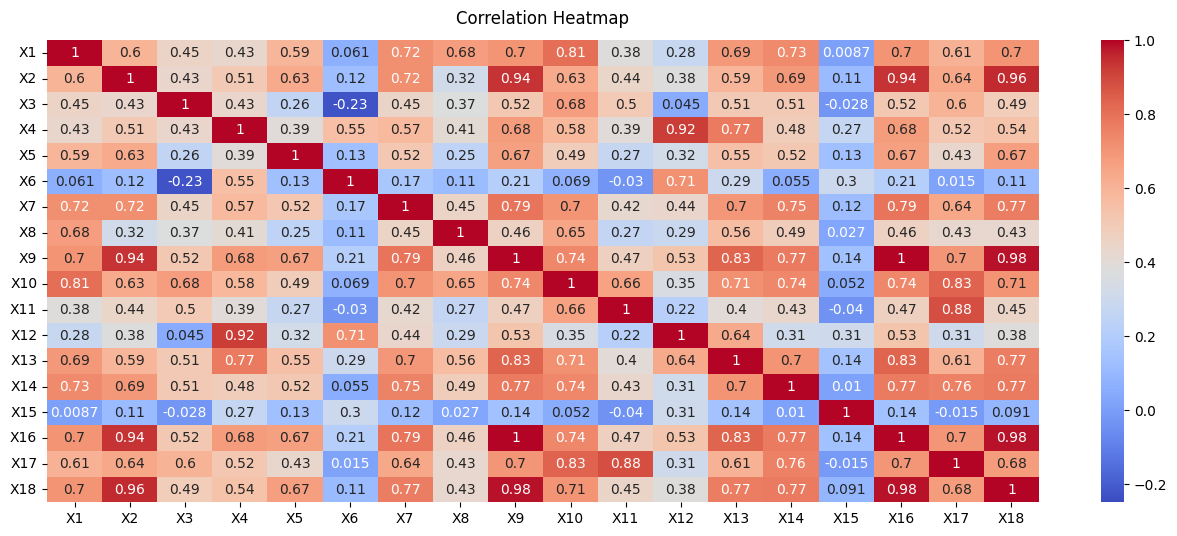

In [4]:
US_df=pd.read_csv('/kaggle/input/company-bankruptcy-prediction-data/american_data.csv')
US_df.head()
print(US_df.shape)

#check NAN
print(US_df.isnull().values.any())
    #no NAN

#remove outlier
col_names=US_df.columns
def remove_outliers(d,columns,n_std):
    for col in columns:
        # print('Working on column: {}'.format(col))
        mean = d[col].mean()
        sd = d[col].std()
        d = d[(d[col] <= mean+(n_std*sd))]
    return d
US_data=remove_outliers(US_df,col_names[2:],3)
print(US_data.shape)

#browse data
print(round(len(US_df[US_df['status_label']=='alive'])/len(US_df),3),round(len(US_df[US_df['status_label']!='alive'])/len(US_df),3))
        #before removing outliers, 6.6% bankrupted, 93.4% survived
print(round(len(US_data[US_data['status_label']=='alive'])/len(US_data),3),round(len(US_data[US_data['status_label']!='alive'])/len(US_df),3))
        #after removing outliers, 4.9% bankrupted, 93.1% survived
display(US_data.describe())

#seperate categorical features from continous features
    # US_data.info()
Cat_col=US_data.select_dtypes(exclude=['float64']).columns
print(len(Cat_col),list(Cat_col))
Num_col=US_data.select_dtypes(include=['float64']).columns
print(len(Num_col),list(Num_col))

#heatmap
plt.figure(figsize=(16, 6))
heatmap_data=US_data.drop(columns=list(Cat_col))
heatmap = sns.heatmap(heatmap_data.corr(), cmap='coolwarm',vmin=-0.25, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12)
    #many are correlated, so use PCA.
        #before PCA, standardize data

<h1 align="left"><font color='blue'><font size = 2> 1.2 Data preprocessing and engineering </font></h1><a class='anchor' id='subsection12'></a>

In [13]:
#standarize data
US_data_stdiz=US_data.drop(columns=list(Cat_col))
US_data_stdiz = (US_data_stdiz-US_data_stdiz.mean())/US_data_stdiz.std()
US_data_stdiz=pd.merge(US_data[Cat_col],US_data_stdiz,left_index=True,right_index=True).reset_index()

#re-code status_label
US_data_stdiz.loc[US_data_stdiz['status_label']=='alive','status_label']=int(0)
US_data_stdiz.loc[US_data_stdiz['status_label']=='failed','status_label']=int(1)

display(US_data_stdiz)





,index,company_name,status_label,year,X1,X2,X3,X4,X5,X6,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,0,C_1,0,1999,3.110495,4.392141,0.441263,1.449148,8.146459,0.665350,...,3.565294,1.839790,1.576943,1.414285,1.268476,2.192348,0.574876,3.565294,2.106479,3.745496
1,1,C_1,0,2000,2.920199,3.664726,0.451558,0.959368,7.750266,0.382759,...,2.934536,1.705386,1.571833,0.866733,0.963402,1.505695,0.581875,2.934536,1.833477,3.139638
2,2,C_1,0,2001,2.551753,2.522445,0.649347,0.221441,6.877089,-0.933515,...,1.944618,1.734039,1.990799,-0.037758,0.485702,1.953742,0.433417,1.944618,2.096070,2.181319
3,3,C_1,0,2002,2.250377,2.341165,0.885341,0.291699,6.193124,-0.142952,...,1.808513,1.653082,1.401533,-0.062815,0.459399,2.902858,0.397727,1.808513,2.038984,2.007784
4,4,C_1,0,2003,2.518413,2.503085,0.860510,0.624242,5.866755,0.127439,...,2.000252,1.730925,2.334831,0.316737,0.648358,1.610576,0.415640,2.000252,2.148449,2.147275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56429,78665,C_8968,0,2017,-0.693016,-0.686513,-0.483131,-0.530268,-0.482537,-0.117126,...,-0.739618,-0.692592,-0.427756,-0.377171,-0.628259,-0.607304,-0.484856,-0.739618,-0.595390,-0.721136
56430,78677,C_8971,0,2014,1.028209,-0.423525,0.225305,0.586989,-0.395840,0.497107,...,-0.301805,3.069369,1.623815,0.552553,-0.023305,-0.231221,0.176611,-0.301805,0.903245,-0.489699
56431,78679,C_8971,0,2016,-0.239184,-0.266598,2.797366,1.250964,-0.416256,0.043403,...,-0.025950,5.291362,7.171065,0.166638,0.372125,0.797544,0.471965,-0.025950,4.633258,-0.334150
56432,78680,C_8971,0,2017,0.294283,-0.282129,2.811144,1.054766,-0.430842,-0.278725,...,-0.059464,5.256597,7.282717,-0.056914,0.318339,0.730440,0.424983,-0.059464,4.677551,-0.324942


<h1 align="left"><font color='blue'><font size = 2> 1.3 Applying 7 ML algorithms to predict bankrumptycy </font></h1><a class='anchor' id='subsection13'></a>

In [ ]:
###KNN Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={
        'n_neighbors': np.arange(2,20,5),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)

# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

knn_full = KNeighborsClassifier(algorithm=best_params['algorithm'],n_neighbors=best_params['n_neighbors'],weights=best_params['weights'])
knn_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

In [ ]:
###Random Forest Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'max_depth': [10, 50, 100, None],# 'max_features': ['auto', 'sqrt'],
            'min_samples_leaf': [1, 2, 4],# 'min_samples_split': [2, 5, 10],
            'n_estimators': [10, 100, 1000]} #split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

RF_full = RandomForestClassifier(
            max_depth=best_params['max_depth'],
            # max_features=best_params['max_features'],
            min_samples_leaf=best_params['min_samples_leaf'],
            n_estimators=best_params['n_estimators']
)
RF_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

In [ ]:
###Logistic Regression Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'solver' : ['newton-cg', 'lbfgs', 'liblinear'],
            'penalty' :['None', 'l1', 'l2', 'elasticnet'],
            'C' :[1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
            }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

LR_full = LogisticRegression(
            solver= best_params['solver'],
            penalty=best_params['penalty'],
            C=best_params['C']
)
LR_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

In [ ]:
###SVM Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'C': [0.1, 1, 10, 100, 1000], 
            'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
            'kernel': ['linear','rbf']
            }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

svm_full = SVC(
            C= best_params['C'],
            gamma=best_params['gamma'],
            kernel=best_params['kernel']
)
svm_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

In [ ]:
###Naive Bayes Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid={'var_smoothing': np.logspace(0,-9, num=100)
            }
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(GaussianNB(), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

NB_full = GaussianNB(
            var_smoothing= best_params['var_smoothing'],
        )
NB_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})

In [ ]:
###Neural Network Model with all features with smote

# Define the parameter grid for the entire pipeline
param_grid = {
    'hidden_layer_sizes': [(10,30,10),(20,)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive']
}
#split data into training and test
x_train, x_test,y_train, y_test = train_test_split(US_data_stdiz.iloc[:,4:],US_data_stdiz.iloc[:,2].values.astype('int'),
                                   random_state=42, 
                                   test_size=0.25, 
                                   shuffle=True)
# print(x_train,y_train,y_train.dtypes)
# Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
grid_search = GridSearchCV(MLPClassifier(max_iter=500), param_grid, cv=10, scoring='recall')  # or RandomizedSearchCV

#conduct SMOTE during RidsearchCV,not before it
pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), grid_search)

# Fit the pipeline with hyperparameter tuning on the training data
model = pipeline.fit(x_train, y_train)

# Best hyperparameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(best_params,best_model)

# Print best hyperparameters
print("Best hyperparameters:", best_params)

#print confusion matrix and report
smt=SMOTE(sampling_strategy='minority')
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

NN_full = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation= best_params['activation'],
    solver=best_params['solver'],
    alpha=best_params['alpha'],
    learning_rate=best_params['learning_rate']
)
NN_full.fit(x_train_sm,y_train_sm)

report = classification_report(y_test, best_model.predict(x_test), output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
display(df_classification_report)
sns.heatmap(confusion_matrix(y_test,best_model.predict(x_test)), fmt='d',cmap='coolwarm',annot=True,annot_kws={'size':18})